# 🏥 Healthcare Insurance Data

## Objective of This Session
- Understand real healthcare insurance data
- Understand WHY we use each function
- Visualize insights using Matplotlib and Seaborn


## 🌍 Why Health Insurance Data Matters in Real Life
Insurance companies use data to:
- Calculate premium pricing
- Identify high-risk customers
- Understand medical cost trends
- Make strategic business decisions

Before building models, companies FIRST explore the data.
This step is called Exploratory Data Analysis (EDA).

## ⬇️ How to Download the Dataset
1. Visit the Kaggle dataset page.
2. Download the ZIP file.
3. Extract it.
4. Place `insurance.csv` in the same folder as this notebook.


## 📦 Import Required Libraries
We will use only:
- Pandas → Data manipulation
- Matplotlib → Basic visualization
- Seaborn → Advanced visualization

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

## 📂 Load the Dataset
We read the CSV file into a Pandas DataFrame.

Think of DataFrame as an Excel sheet inside Python.

In [3]:
# the file is in the notebook directory, not in “data/”
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 🔎 Understanding the Structure (Pandas Basics)

Before analysis, we must understand:
- How many rows?
- How many columns?
- What are the data types?
- Any missing values?

In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# 📊 Understanding groupby() 

### What is groupby()?
`groupby()` is used when we want to:
- Split data into groups
- Apply a calculation (like mean, sum, count)
- Combine results

This is called the Split–Apply–Combine strategy.

### Why do we need groupby() in industry?
Industry professionals ask questions like:
- What is the average insurance charge for smokers?
- What is the average charge per region?
- What is the total revenue by category?

To answer these, we must group similar rows together.

## 🧠 Simple Example Before Using Our Dataset
Imagine we have sales data:
- Store A
- Store B

If we want average sales per store,
we must group by store first.

## 📊 Applying groupby() to Our Insurance Data

### Industry Question:
Do smokers pay more on average?

This means:

Split data into two groups:

smoker = yes

smoker = no

Compute average charges inside each group.

In [8]:
df.groupby('smoker')['charges'].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

### Industry Question:
Which region has the highest average insurance charges?

In [9]:
df.groupby('region')['charges'].mean()

region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

# 📈 Matplotlib – Basic Visualization

### Why do we visualize?
Because numbers alone are hard to interpret.
Charts help us see patterns quickly.

# Question 1:
Do older people pay higher medical insurance charges?

If age increases, do charges also increase?

To answer this, we use a Scatter Plot.

Why scatter plot?

Because:
- Both age and charges are numerical variables
- Scatter plots show relationship between two numbers
- Each dot represents one person

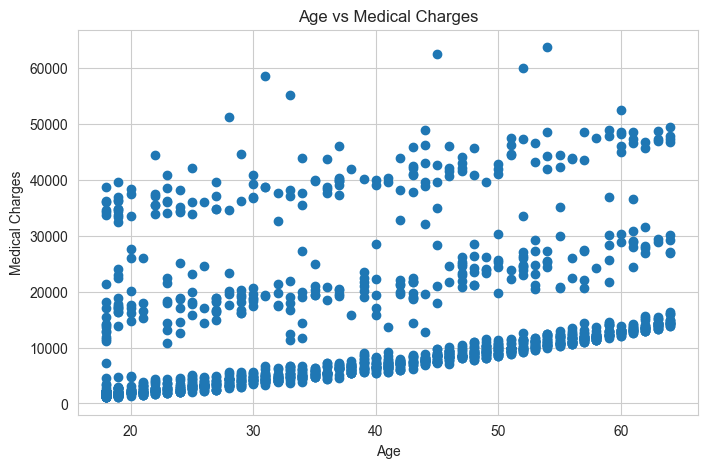

In [10]:
# Create figure size for better visibility
plt.figure(figsize=(8,5))

# Scatter plot: Age vs Charges
plt.scatter(df['age'], df['charges'])

# Labeling axes
plt.xlabel("Age")
plt.ylabel("Medical Charges")

# Adding title
plt.title("Age vs Medical Charges")

# Show plot
plt.show()

Interpretation:

- If dots trend upward → Positive correlation
- If dots are random → No correlation
- If dots trend downward → Negative correlation

In insurance:
If age increases cost,
premium should increase with age.

# Question: What is the Distribution of BMI?

# Question 2:
How is BMI distributed in our dataset?

Are most people overweight?
Are there extreme values?

To answer this, we use a Histogram.

Why histogram?

Because:
- It shows distribution of one numerical variable
- It groups values into bins
- Helps detect skewness and spread

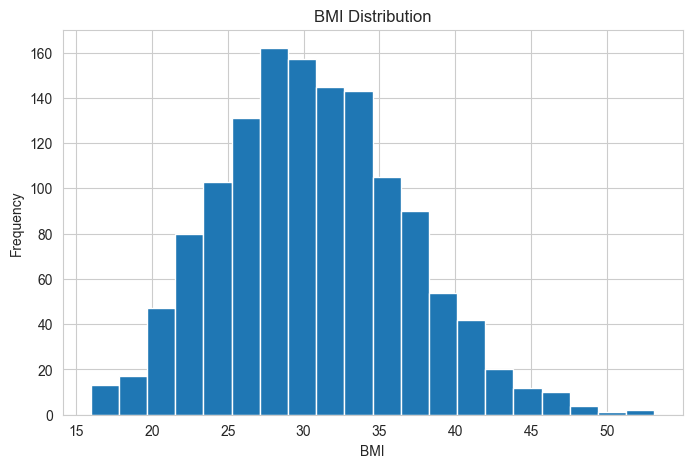

In [11]:
plt.figure(figsize=(8,5))

# Plot histogram
plt.hist(df['bmi'], bins=20)

# Labels
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.title("BMI Distribution")

plt.show()

Interpretation:

- Peak area shows most common BMI range
- Long tail → possible extreme values
- If many people have high BMI,
insurance risk increases.

# Question: Do Smokers Pay More on Average?

# Question 3:
Is there a difference in average charges between smokers and non-smokers?

To compare categories,
we use a Bar Chart.

Why bar chart?

Because:
- smoker is categorical
- charges mean is numerical
- Bar charts compare group averages

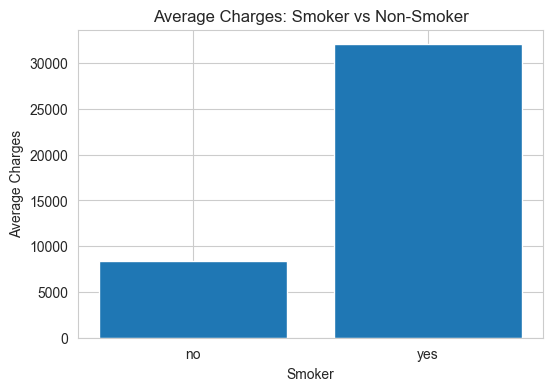

In [12]:
# Calculate average charges for each group
avg_charges = df.groupby('smoker')['charges'].mean()

plt.figure(figsize=(6,4))

# Create bar chart
plt.bar(avg_charges.index, avg_charges.values)

plt.xlabel("Smoker")
plt.ylabel("Average Charges")

plt.title("Average Charges: Smoker vs Non-Smoker")

plt.show()

Interpretation:

If smoker bar is significantly higher,
smoking increases medical cost.

Business action:
Higher premium for smokers.

# How Do Charges Change Across Age Groups?

# Question 4:
Instead of individual age points,
can we see average charges by age group?

We will:

1. Create age bins
2. Compute average charges per bin
3. Plot a Line Graph

Why line graph?

Because:
- It shows trend clearly
- Helps see gradual increase or decrease

C:\Users\gears\AppData\Local\Temp\ipykernel_33976\724541195.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_mean = df.groupby('age_group')['charges'].mean()


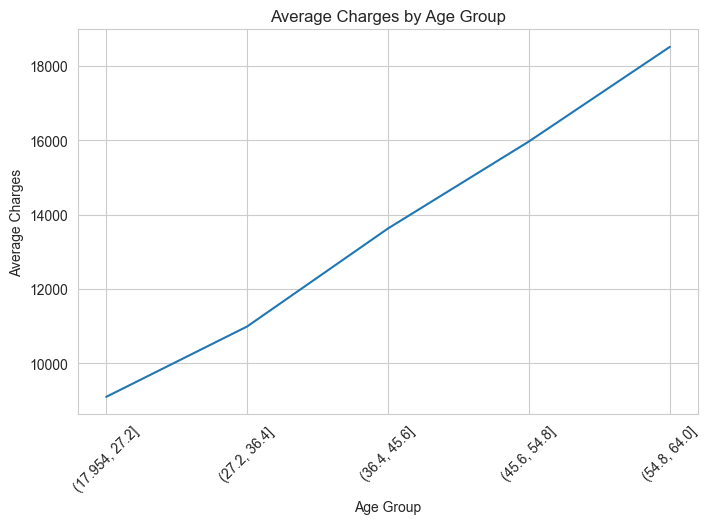

In [13]:
# Create age bins
df['age_group'] = pd.cut(df['age'], bins=5)

# Calculate mean charges per group
age_group_mean = df.groupby('age_group')['charges'].mean()

plt.figure(figsize=(8,5))

# Line plot
plt.plot(age_group_mean.index.astype(str), age_group_mean.values)

plt.xticks(rotation=45)
plt.xlabel("Age Group")
plt.ylabel("Average Charges")

plt.title("Average Charges by Age Group")

plt.show()

### Industry Question:
What is the age distribution of insured individuals?

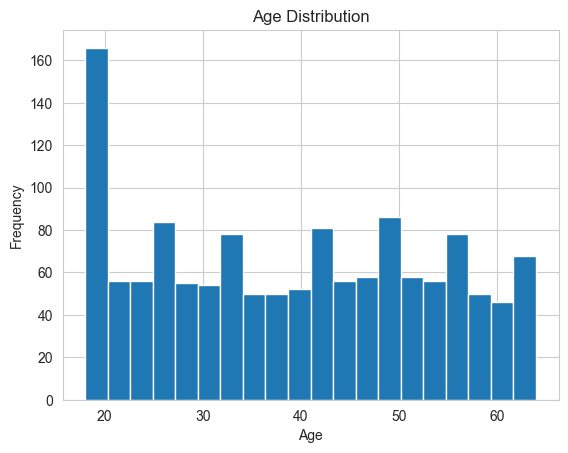

In [14]:
plt.figure()
plt.hist(df['age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 📊 Seaborn – Advanced Visualization


# Why Seaborn?

Matplotlib is powerful but basic.

Seaborn is built on top of matplotlib.

It provides:

- Better default styling
- Statistical visualizations
- Easier multi-variable plotting
- Built-in aggregation

In simple words:

Matplotlib → Draw graphs  
Seaborn → Understand patterns

## SEABORN PLOT 1 — Boxplot

# Question 1:
Do smokers and non-smokers have different charge distributions?

Not just average.
We want to see:

- Median
- Spread
- Extreme values
- Outliers

For this, we use a Boxplot.

# What is a Boxplot?

A boxplot shows:

- Middle line → Median
- Box → 25th to 75th percentile (spread)
- Whiskers → Data range
- Dots → Outliers

Why useful?

Because average alone can be misleading.
Boxplot shows entire distribution.

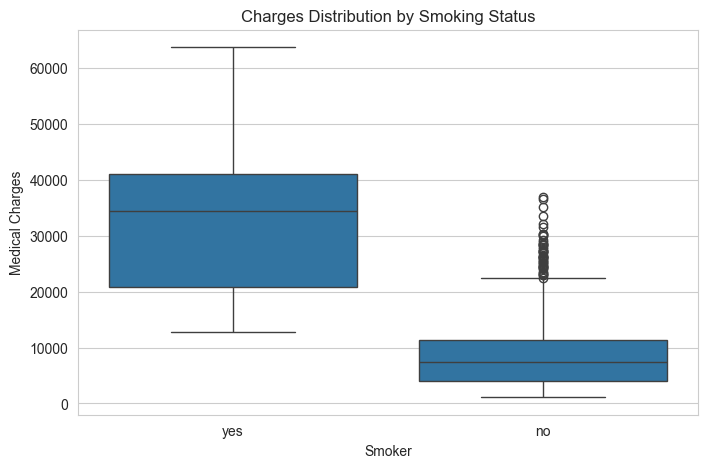

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x='smoker', y='charges', data=df)

plt.title("Charges Distribution by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Medical Charges")

plt.show()

If smoker box is:

- Higher median → Smokers pay more
- Larger spread → High variability
- Many outliers → Extreme medical cases

Business Decision:
Smokers are high-risk group.
Premium should be adjusted.

# SEABORN PLOT 2 — Regression Plot (Advanced Statistical Plot)

# Question 2:
What is the statistical relationship between age and charges?

We already saw scatter plot using matplotlib.

Now we use seaborn's regression plot.

It automatically:

- Plots scatter points
- Calculates best fit line
- Adds confidence interval

# What is Regression Plot?

Regression plot shows:

- Data points
- Best fit line
- Confidence band (uncertainty)

This helps us visually understand:

Is relationship linear?
How strong is trend?

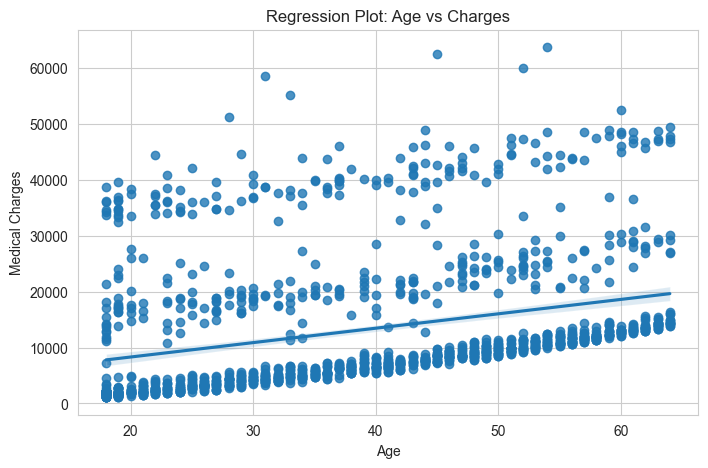

In [16]:
plt.figure(figsize=(8,5))

sns.regplot(x='age', y='charges', data=df)

plt.title("Regression Plot: Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Medical Charges")

plt.show()

If line slopes upward → Positive correlation.

Shaded region → Confidence interval.
Narrow band → More reliable trend.

This plot directly connects to:

Linear Regression (Machine Learning).

Seaborn makes statistical visualization easy.

### Industry Question:
Is there a relationship between age and insurance charges?

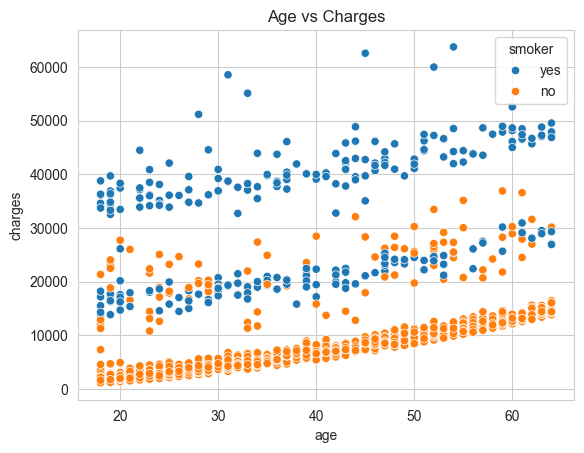

In [17]:
plt.figure()
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title('Age vs Charges')
plt.show()

### Industry Question 2 :
Which variables are strongly correlated with charges?

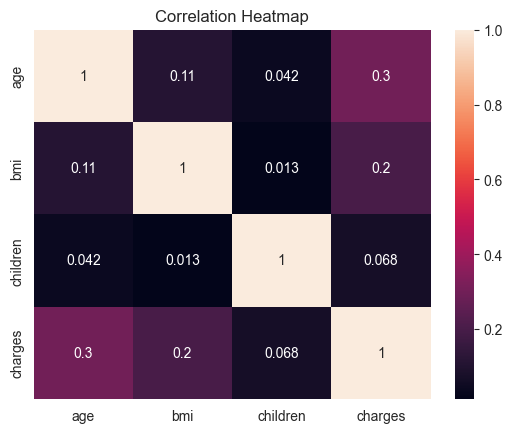

In [18]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()